# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Silvia Melani Siregar
- **Email:** cdcc185d6x2017@student.devacademy.id
- **ID Dicoding:** CDCC185D6X2017

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah penyewaan sepeda (cnt) pada tahun 2011-2012?
- Kapan waktu (jam dan hari) dengan jumlah penyewaan sepeda tertinggi, dan bagaimana pola tersebut selama periode 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [63]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [64]:
day_df = pd.read_csv('day.csv')
day_df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [65]:
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset berhasil dimuat ke dalam DataFrame yang terdiri dari dua jenis data, yaitu data harian (day.csv) dan data per jam (hour.csv) sehingga memungkinkan analisis dilakukan pada dua tingkat waktu yang berbeda
- Dari tampilan awal data, terlihat bahwa dataset memuat informasi waktu serta berbagai variabel pendukung seperti kondisi cuaca, suhu, kelembapan, dan jumlah pengguna, yang dapat digunakan untuuk menganalisis faktor-faktor yang mempengaruhi penyewaan sepeda.

### Assessing Data

In [66]:
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

**Insight:** Pada tahap ini dilakukan pengecekan struktur dataset untuk memahami tipe data setiap kolom serta jumlah data yang tersedia.

Berdasarkan hasil .info(), sebagian besar kolom pada kedua dataset sudah bertipe numerik, sehingga siap digunakan untuk analisis. Namun, kolom dteday masih bertipe object, sehingga perlu dikonversi menjadi tipe datetime agar dapat digunakan untuk analisis berbasis waktu dengan lebih optimal.

Selain itu, jumlah data pada setiap kolom terlihat konsisten, yang menunjukkan tidak adanya indikasi missing values pada tahap awal ini.

In [67]:
day_df.isna().sum()
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Insight:** Langkah ini bertujuan untuk mengidentifikasi apakah terdapat nilai yang hilang (missing values) dalam dataset.

Berdasarkan hasil pengecekan, tidak ditemukan adanya missing values pada kedua dataset. Hal ini menunjukkan bahwa data yang digunakan sudah lengkap dan tidak memerlukan penanganan khusus seperti imputasi atau penghapusan data.

In [68]:
day_df.duplicated().sum()
hour_df.duplicated().sum()

np.int64(0)

In [69]:
day_df.describe()
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Berdasarkan hasil pengecekan, kedua dataset tersebut tidak terdeteksi adanya missing values dan tidak ditemukan data duplikat, sehingga kualitas data tergolong baik dan siap digunakan untuk analisis lebih lanjut tanpa perlu penanganan khusus terkait kelengkapan data.
- Struktur dataset didominasi oleh tipe data numerik, namun terdapat kolom *dteday* yang masih bertipe object, sehingga perlu dilakukan konversi ke tipe datetime agar dapat dianalisis berdasarkan waktu dengan lebih optimal.

### Cleaning Data

In [70]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

**Insight:**
Pada tahap ini dilakukan konversi tipe data pada kolom dteday dari object menjadi datetime.

Perubahan ini diperlukan karena sebelumnya kolom tanggal masih terbaca sebagai teks, sehingga belum dapat digunakan secara optimal untuk analisis berbasis waktu.

Dengan mengubahnya menjadi tipe datetime, data dapat lebih mudah diolah untuk kebutuhan analisis lanjutan, seperti:
- Mengelompokkan data berdasarkan waktu (hari, bulan, atau tahun),
- Menganalisis pola penggunaan berdasarkan periode tertentu,
- Mempermudah proses visualisasi data berbasis waktu.

## Exploratory Data Analysis (EDA)

### Explore ...

In [71]:
day_df.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


Pada tahap awal EDA, dilakukan analisis statistik deskriptif untuk memahami gambaran umum distribusi data, khususnya pada variabel jumlah penyewaan sepeda (cnt). Fungsi .describe() digunakan untuk melihat nilai rata-rata, minimum, maksimum, serta sebaran data melalui kuartil.

**Insight:**
Berdasarkan hasil statistik deskriptif, jumlah penyewaan sepeda memiliki rentang nilai yang cukup lebar antara nilai minimum dan maksimum. Hal ini menunjukkan bahwa tingkat penggunaan sepeda tidak stabil dan bervariasi dari waktu ke waktu, yang mengindikasikan adanya pengaruh faktor eksternal seperti kondisi cuaca dan waktu.

In [72]:
day_df.groupby('season')['cnt'].mean()

,cnt
season,
1,2604.132597
2,4992.331522
3,5644.303191
4,4728.162921


Analisis ini bertujuan untuk melihat bagaimana rata-rata jumlah penyewaan sepeda berbeda pada setiap musim. Data dikelompokkan berdasarkan variabel season, kemudian dihitung nilai rata-rata penyewaan (cnt) pada masing-masing kelompok.

**Insight:**
Hasil menunjukkan bahwa terdapat perbedaan rata-rata penyewaan sepeda pada setiap musim. Hal ini mengindikasikan bahwa faktor musiman memiliki pengaruh terhadap tingkat penggunaan sepeda, di mana kondisi lingkungan pada musim tertentu dapat mendorong atau menghambat aktivitas bersepeda.

In [73]:
day_df.groupby('weathersit')['cnt'].mean()

,cnt
weathersit,
1,4876.786177
2,4035.862348
3,1803.285714


Pada tahap ini dilakukan analisis untuk melihat pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda. Data dikelompokkan berdasarkan kategori cuaca (weathersit), kemudian dihitung rata-rata jumlah penyewaan pada masing-masing kondisi.

**Insight:**
Kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Cuaca cerah menghasilkan tingkat penyewaan tertinggi, sedangkan kondisi seperti kabut dan hujan ringan menunjukkan penurunan jumlah penyewaan. Hal ini menunjukkan bahwa kenyamanan dan keamanan menjadi faktor utama dalam keputusan pengguna untuk menggunakan sepeda.

In [74]:
hour_df.groupby('hr')['cnt'].mean()

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


Untuk memahami pola penggunaan secara lebih detail, analisis dilanjutkan menggunakan data per jam (hour_df). Data dikelompokkan berdasarkan jam (hr) untuk melihat rata-rata jumlah penyewaan pada setiap waktu dalam sehari.

**Insight:** Terdapat pola penggunaan sepeda yang jelas dalam satu hari. Penyewaan meningkat pada pagi hari (sekitar jam 7–9) dan sore hari (sekitar jam 16–18), sementara pada malam hingga dini hari jumlah penyewaan sangat rendah. Pola ini menunjukkan bahwa sepeda digunakan sebagai sarana transportasi rutin untuk aktivitas sehari-hari.

In [75]:
hour_df.groupby('weekday')['cnt'].mean()

,cnt
weekday,
0,177.468825
1,183.744655
2,191.238891
3,191.130505
4,196.436665
5,196.135907
6,190.209793


Analisis ini bertujuan untuk melihat perbedaan pola penyewaan sepeda berdasarkan hari dalam seminggu. Data dikelompokkan berdasarkan variabel weekday, kemudian dihitung rata-rata jumlah penyewaan.

**Insight:** Pola penyewaan sepeda juga bervariasi berdasarkan hari, penyewaan sepeda cenderung lebih tinggi pada hari kerja dibandingkan akhir pekan. Hal ini mengindikasikan bahwa sepeda lebih sering digunakan untuk aktivitas rutin seperti bekerja atau sekolah dibandingkan untuk keperluan rekreasi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah penyewaan sepeda (cnt) pada tahun 2011-2012?

In [76]:
day_df['weathersit'].unique()

array([2, 1, 3])

**Insight:** Kode ini digunakan untuk melihat kategori unik pada variabel weathersit. Hal ini penting untuk memahami representasi data cuaca sebelum dilakukan transformasi ke bentuk yang lebih deskriptif.

In [77]:
weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

day_df['weathersit_label'] = day_df['weathersit'].map(weather_map)

**Insight:** Pada tahap ini, nilai numerik pada variabel weathersit diubah menjadi label yang lebih mudah dipahami agar visualisasi dan interpretasi hasil menjadi lebih intuitif.

In [78]:
day_df[['weathersit', 'weathersit_label']].head()

,weathersit,weathersit_label
0,2,Mist
1,2,Mist
2,1,Clear
3,1,Clear
4,1,Clear


**Inisight:** Hasil mapping digunakan untuk memastikan bahwa proses mapping berhasil dan setiap nilai numerik telah sesuai dengan label cuaca yang diinginkan.

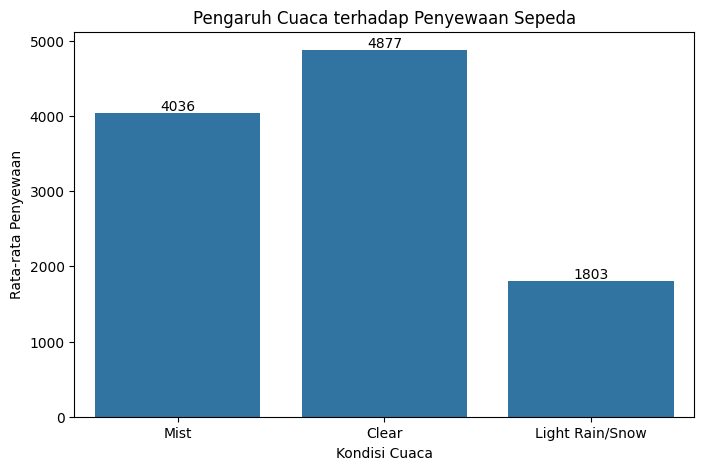

In [79]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=day_df,
    x='weathersit_label',
    y='cnt',
    errorbar=None
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title('Pengaruh Cuaca terhadap Penyewaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:** Berdasarkan hasil perhitungan rata-rata penyewaan sepeda pada setiap kondisi cuaca, terlihat bahwa kategori Clear memiliki nilai rata-rata tertinggi dibandingkan kategori lainnya. Hal ini menunjukkan bahwa kondisi cuaca yang cerah sangat mendukung peningkatan aktivitas penyewaan sepeda.

Sebaliknya, pada kondisi Mist dan Light Rain/Snow, rata-rata penyewaan mengalami penurunan yang cukup signifikan. Penurunan ini mengindikasikan bahwa pengguna cenderung mengurangi aktivitas bersepeda ketika kondisi cuaca kurang mendukung, baik karena faktor kenyamanan maupun keamanan.

Selain itu, kategori Heavy Rain/Snow umumnya memiliki nilai rata-rata paling rendah atau jumlah data yang sangat sedikit, yang menunjukkan bahwa aktivitas bersepeda hampir tidak dilakukan pada kondisi cuaca ekstrem.

Dengan demikian, dapat disimpulkan bahwa terdapat hubungan yang jelas antara kondisi cuaca dan jumlah penyewaan sepeda, di mana semakin baik kondisi cuaca, semakin tinggi pula tingkat penggunaan sepeda.

### Pertanyaan 2: Kapan waktu (jam dan hari) dengan jumlah penyewaan sepeda tertinggi, dan bagaimana pola tersebut selama periode 2011–2012?

In [80]:
hourly_avg = hour_df.groupby('hr')['cnt'].mean()
hourly_avg

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


Kode ini menghitung rata-rata jumlah penyewaan sepeda untuk setiap jam dalam sehari (0–23) guna melihat pola penggunaan berdasarkan waktu.

**Insight:** Hasil perhitungan menunjukkan bahwa jumlah penyewaan sepeda berbeda-beda pada setiap jam. Hal ini menandakan bahwa adanya pola penggunaan sepeda dalam satu hari.

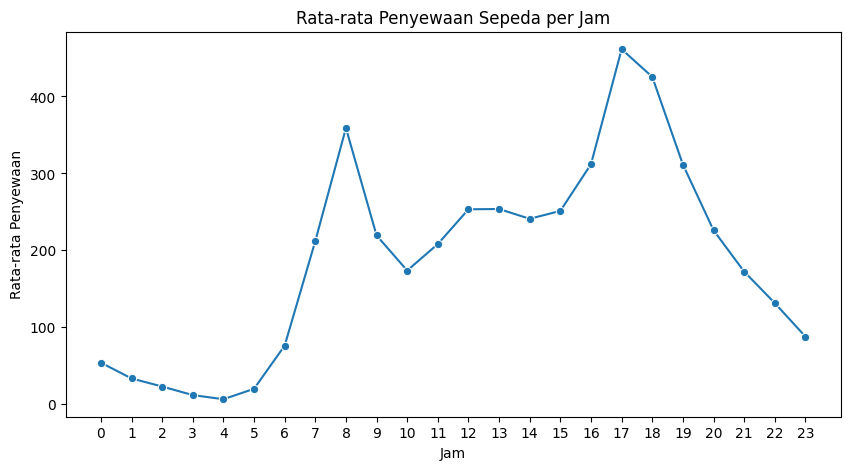

In [81]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_avg.index,
    y=hourly_avg.values,
    marker='o'
)

plt.title('Rata-rata Penyewaan Sepeda per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0,24))
plt.show()

**Insight:**  Dari grafik terlihat pola yang sangat jelas bahwa penyewaan sepeda tidak merata sepanjang hari, melainkan membentuk pola dua puncak (bimodal).

Puncak pertama terjadi pada pagi hari sekitar jam 08.00, sedangkan puncak kedua terjadi pada sore hari sekitar jam 17.00–18.00. Kedua waktu ini menunjukkan jumlah penyewaan tertinggi dibandingkan jam lainnya.

Sebaliknya, pada dini hari hingga subuh (sekitar jam 00.00–05.00), jumlah penyewaan berada pada titik terendah. Hal ini menunjukkan bahwa aktivitas bersepeda sangat minim pada jam-jam tersebut.

Pola ini mengindikasikan bahwa sepeda banyak digunakan sebagai sarana transportasi rutin, terutama untuk aktivitas seperti berangkat dan pulang kerja atau sekolah.

In [82]:
day_map = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}

hour_df['weekday_label'] = hour_df['weekday'].map(day_map)

**Insight:** Pada kode ini, nilai numerik pada kolom weekday (0–6) diubah menjadi nama hari (Sunday–Saturday). Tujuannya agar hasil analisis dan visualisasi lebih mudah dipahami dibandingkan hanya menggunakan angka.

In [83]:
daily_avg = hour_df.groupby('weekday_label')['cnt'].mean()

daily_avg = daily_avg.reindex([
    'Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'
])

daily_avg

,cnt
weekday_label,
Sunday,177.468825
Monday,183.744655
Tuesday,191.238891
Wednesday,191.130505
Thursday,196.436665
Friday,196.135907
Saturday,190.209793


**Insight:** Kode ini digunakan untuk menghitung rata-rata jumlah penyewaan sepeda (cnt) untuk setiap hari.
Fungsi reindex() digunakan untuk mengurutkan hari agar sesuai dengan urutan kalender, sehingga tidak acak saat divisualisasikan.

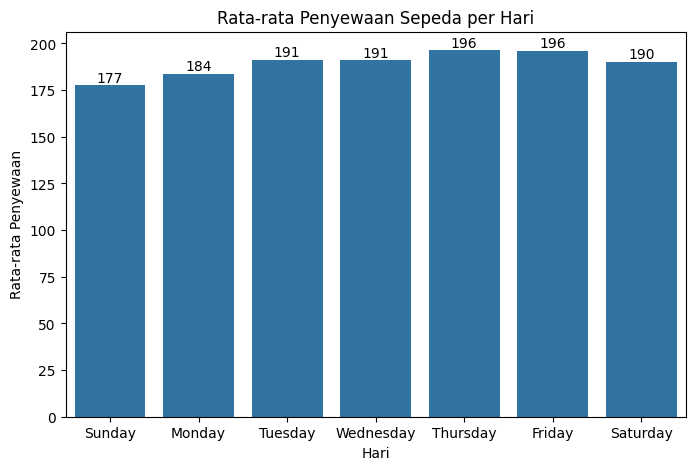

In [84]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=daily_avg.index,
    y=daily_avg.values
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title('Rata-rata Penyewaan Sepeda per Hari')
plt.xlabel('Hari')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

Visualisasi ini digunakan untuk membandingkan rata-rata penyewaan sepeda pada setiap hari dalam satu minggu.
Penambahan anotasi angka pada setiap batang bertujuan agar nilai rata-rata dapat langsung dibaca tanpa harus memperkirakan dari grafik.

**Insight:** Berdasarkan visualisasi, terlihat bahwa penyewaan sepeda cenderung lebih tinggi pada hari kerja (Senin hingga Jumat) dibandingkan dengan akhir pekan (Sabtu dan Minggu).

Hal ini menunjukkan bahwa sepeda lebih banyak digunakan sebagai sarana transportasi untuk aktivitas rutin sehari-hari, seperti bekerja atau sekolah. Pola ini juga konsisten dengan temuan sebelumnya pada analisis per jam, di mana terjadi lonjakan pada jam sibuk pagi dan sore hari.

Sebaliknya, pada akhir pekan, jumlah penyewaan relatif lebih rendah dan cenderung stabil tanpa adanya lonjakan signifikan. Hal ini mengindikasikan bahwa penggunaan sepeda untuk keperluan rekreasi tidak sebesar penggunaan untuk aktivitas rutin.

**Insight Kedua Pertanyaan:**
1. Kondisi cuaca berpengaruh terhadap jumlah penyewaan sepeda, di mana cuaca cerah menghasilkan jumlah penyewaan tertinggi dibandingkan kondisi cuaca lainnya.
2. Pola penyewaan sepeda menunjukkan adanya waktu-waktu tertentu dengan jumlah tertinggi, yaitu pada pagi dan sore hari, serta cenderung lebih tinggi pada hari kerja dibandingkan akhir pekan.

## Analisis Lanjutan (Opsional)

Pada tahap ini dilakukan analisis lanjutan menggunakan metode clustering sederhana (manual grouping). Clustering digunakan untuk mengelompokkan data berdasarkan tingkat penyewaan sepeda agar pola penggunaan dapat terlihat lebih jelas.

Dalam analisis ini, data akan dikelompokkan menjadi tiga kategori, yaitu rendah (low), sedang (medium), dan tinggi (high) berdasarkan rata-rata jumlah penyewaan sepeda pada setiap jam. Dengan adanya pengelompokan ini, diharapkan dapat mempermudah dalam mengidentifikasi waktu-waktu dengan tingkat penggunaan sepeda yang berbeda.

In [85]:
hourly_avg = hour_df.groupby('hr')['cnt'].mean().reset_index()
hourly_avg

,hr,cnt
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941
5,5,19.889819
6,6,76.044138
7,7,212.064649
8,8,359.011004
9,9,219.309491


**Insight:** Kode ini digunakan untuk meringkas data jadi rata-rata penyewaan untuk tiap jam (0–23), supaya lebih mudah melihat pola utama tanpa noise dari data harian.

In [86]:
hourly_avg['category'] = pd.cut(
    hourly_avg['cnt'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

hourly_avg

,hr,cnt,category
0,0,53.898072,Low
1,1,33.375691,Low
2,2,22.869930,Low
3,3,11.727403,Low
4,4,6.352941,Low
5,5,19.889819,Low
6,6,76.044138,Low
7,7,212.064649,Medium
8,8,359.011004,High
9,9,219.309491,Medium


**Insight:** Data dibagi menjadi 3 kelompok:
- Low: penyewaan rendah
- Medium: sedang
- High: tinggi

Tujuannya supaya bisa “mengelompokkan” jam berdasarkan intensitas penggunaan.

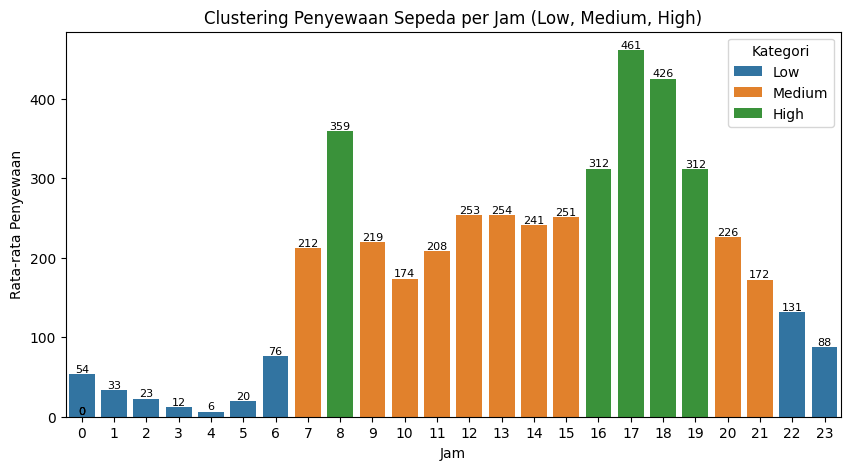

In [87]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=hourly_avg,
    x='hr',
    y='cnt',
    hue='category',
    dodge=False
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.title('Clustering Penyewaan Sepeda per Jam (Low, Medium, High)')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.legend(title='Kategori')
plt.show()

**Insight:** Berdasarkan hasil clustering, terlihat bahwa tingkat penyewaan sepeda tidak merata sepanjang hari, melainkan terbagi ke dalam tiga kategori utama.
- Kategori **High** terkonsentrasi pada jam-jam tertentu, yaitu sekitar pukul 08.00 serta 16.00–18.00, dengan puncak tertinggi terjadi pada pukul 17.00. Hal ini menunjukkan adanya pola penggunaan sepeda yang sangat intens pada waktu-waktu tersebut.
- Kategori **Medium** umumnya berada pada jam di luar puncak, seperti siang hingga malam awal. Pada periode ini, penyewaan tetap berlangsung cukup stabil, namun tidak mencapai tingkat tertinggi.
-Sementara itu, kategori **Low** didominasi oleh jam-jam dini hari hingga pagi awal serta malam larut, dimana aktivitas penyewaan sepeda sangat minim.

Pola ini mengindikasikan bahwa penggunaan sepeda sangat berkaitan dengan aktivitas harian masyarakat, khususnya sebagai sarana transportasi. Jam-jam dengan kategori High merepresentasikan waktu berangkat dan pulang kerja, sedangkan kategori Low mencerminkan waktu dengan mobilitas rendah.

Selain itu, distribusi kategori menunjukkan bahwa sebagian besar jam berada pada kategori Medium, yang berarti penggunaan sepeda relatif stabil sepanjang hari, dengan hanya beberapa jam yang benar-benar menjadi puncak permintaan.

Dengan adanya pengelompokan ini, pola penyewaan sepeda menjadi lebih terstruktur dan mudah diinterpretasikan, sehingga dapat membantu dalam pengambilan keputusan, seperti pengaturan jumlah sepeda pada jam-jam tertentu atau optimalisasi operasional layanan.

## Conclusion

Berdasarkan hasil analisis data penyewaan sepeda tahun 2011–2012, diperoleh beberapa temuan utama yang dapat menjawab pertanyaan bisnis yang telah dirumuskan.
1. Kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Cuaca cerah (Clear) menghasilkan rata-rata penyewaan tertinggi, sedangkan kondisi seperti kabut (Mist) dan hujan ringan (Light Rain/Snow) menunjukkan penurunan jumlah penyewaan. Hal ini menunjukkan bahwa pengguna cenderung lebih aktif menggunakan sepeda saat kondisi cuaca mendukung.
2. Pola penyewaan sepeda menunjukkan adanya waktu-waktu tertentu dengan tingkat penggunaan tertinggi. Berdasarkan analisis per jam, puncak penyewaan terjadi pada pagi hari sekitar pukul 08.00 serta sore hari sekitar pukul 17.00–18.00. Hal ini mengindikasikan bahwa sepeda banyak digunakan sebagai sarana transportasi untuk aktivitas rutin, seperti berangkat dan pulang kerja.
3. Hasil clustering menunjukkan bahwa tingkat penyewaan sepeda dapat dikelompokkan ke dalam tiga kategori, yaitu Low, Medium, dan High. Kategori High hanya muncul pada jam-jam tertentu yang menjadi puncak aktivitas, sementara sebagian besar jam berada pada kategori Medium, yang menunjukkan bahwa penggunaan sepeda relatif stabil sepanjang hari. Kategori Low didominasi oleh jam-jam dengan aktivitas rendah, seperti dini hari dan malam larut.

Secara keseluruhan, dapat disimpulkan bahwa pola penyewaan sepeda dipengaruhi oleh kombinasi faktor cuaca dan waktu. Cuaca berperan sebagai faktor eksternal yang menentukan tingkat kenyamanan pengguna, sedangkan waktu mencerminkan pola aktivitas harian masyarakat.

Temuan ini dapat dimanfaatkan untuk mendukung pengambilan keputusan, seperti pengelolaan ketersediaan sepeda pada jam-jam sibuk, serta perencanaan strategi operasional yang lebih efektif berdasarkan kondisi cuaca dan pola penggunaan.